# TFG: Detección precoz de cáncer colorrectal utilizando técnicas de aprendizaje automático
**Grado en Física - Universidad Europea de Valencia**

* **Presentado por:** Gabriela Hortensia Ramos Mizrachi
* **Tutor:** Héctor Gisbert Mullor
* **Curso:** 2025-2026

---
### Resumen del Notebook
Este notebook documenta el proceso experimental en el cual se prueba el modelo de aprendizaje automatico seleccionado.

# Etapa 2: Optimización mediante aprendizaje automático: 
## Modelo de aprendizaje automatico

### Importación de Librerías y Dependencias
En esta sección se cargan todas las herramientas necesarias para el proyecto:

In [1]:
import os
import re
import shap
import warnings
import numpy as np
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.utils import resample
from sklearn.decomposition import PCA
from imblearn.combine import SMOTETomek
from catboost import CatBoostClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_curve, auc, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report)

### Configuración de Rutas y Parámetros Globales
Se definen las constantes del proyecto para facilitar el mantenimiento del código:
* **RUTA_BASE:** Ubicación de los archivos Excel originales.
* **UMBRAL:** Valor mínimo de abundancia (0.05) para considerar un compuesto como relevante.
* **GRUPOS:** Diccionario que organiza las tres poblaciones de estudio: **Enfermos (M)**, **Sanos (S)** y **Pólipos (P)**, especificando sus carpetas y el número total de muestras.

In [2]:
# Configuración de Rutas y Parámetros 
RUTA_BASE = r"C:\Users\User\OneDrive\Documentos\TFG\Gabriela"
UMBRAL = 0.05 
OUTPUT_FILE = 'data_prepared.xlsx'
GRUPOS = {
    "M": {"carpeta": "ENFERMOS", "prefijo": "M", "n": 58},
    "S": {"carpeta": "SANOS", "prefijo": "S", "n": 48},
    "P": {"carpeta": "POLIPOS", "prefijo": "P", "n": 41}
}

### Definición del Vector de Características (Top 100 Compuestos)
En este paso se realiza el primer análisis de los datos:
1. Se define la función `obtener_nombres_validos` para leer cada Excel, filtrar por el umbral de abundancia y limpiar los nombres de los compuestos (eliminando sufijos innecesarios).
2. Se recorren todas las muestras para contar la frecuencia de aparición de cada compuesto en toda la población.
3. Se seleccionan los **100 compuestos más frecuentes** para formar el vector de características base de nuestro modelo.

In [3]:
def obtener_nombres_validos(ruta, umbral):
    """Extrae nombres únicos que superan el umbral de abundancia."""
    try:
        df = pd.read_excel(ruta, header=None)
        
        # Localizar el inicio de los datos (buscando 'Library/ID' o '1=')
        mask = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        if not mask.any(): return set()
        idx_inicio = mask.idxmax()
        
        data = df.iloc[idx_inicio + 1:].copy()
        
        # Columna 3: Abundancia, Columna 4: Nombre del compuesto
        data[3] = pd.to_numeric(data[3], errors='coerce')
        
        # Filtrar por abundancia y limpiar nombres
        filtro = (data[3] >= umbral) & (data[4].notna())
        nombres = data.loc[filtro, 4].astype(str).apply(lambda x: x.split('$$')[0].strip())
        
        return set(nombres)
    except Exception:
        return set()

# Procesamiento de todas las poblaciones
conteo_global = pd.DataFrame()

for etiqueta, info in GRUPOS.items():
    dir_path = os.path.join(RUTA_BASE, info["carpeta"])
    
    for i in range(1, info["n"] + 1):
        file_path = os.path.join(dir_path, f"{info['prefijo']} ({i}).xlsx")
        
        if os.path.exists(file_path):
            nombres_muestra = obtener_nombres_validos(file_path, UMBRAL)
            # Crear DataFrame temporal para sumar al conteo
            temp_df = pd.DataFrame({'Name': list(nombres_muestra), 'Count': 1})
            conteo_global = pd.concat([conteo_global, temp_df], ignore_index=True)

# Generación del Vector de Características
# Agrupamos por nombre y sumamos cuántas veces aparece en TOTAL (M + S + P)
top_names_series = conteo_global.groupby('Name')['Count'].sum()

# Ordenar por frecuencia y tomar los 100 más comunes
top_names = top_names_series.sort_values(ascending=False).head(100)
top_names_vector = top_names.index.to_list()


### Construcción de la Matriz de Datos (Preparación Final)
Una vez identificado el vector de características, transformamos las muestras individuales en una estructura apta para aprendizaje automático:
* **Matriz Binaria:** Se crea un DataFrame donde las filas son las muestras y las columnas son los compuestos del Top 100.
* **Codificación:** Se asigna un `1` si el compuesto está presente en la muestra superando el umbral y un `0` en caso contrario.
* **Etiquetado:** Se añade la columna `State` para identificar la clase (M, S o P).
* **Exportación:** El resultado se guarda en `data_prepared.xlsx`.

In [ ]:
def procesar_nombres_muestra(ruta, umbral):
    """Extrae y limpia nombres de compuestos que superan el umbral."""
    try:
        df = pd.read_excel(ruta, header=None)
        # Localizar el inicio de los datos
        mask = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        if not mask.any(): return set()
        idx_inicio = mask.idxmax()
        
        data = df.iloc[idx_inicio + 1:].copy()
        data[3] = pd.to_numeric(data[3], errors='coerce') # Columna de abundancia
        
        # Filtrar y limpiar (quita $$ y espacios)
        filtro = (data[3] >= umbral) & (data[4].notna())
        nombres = data.loc[filtro, 4].astype(str).apply(lambda x: x.split('$$')[0].strip())
        return set(nombres)
    except Exception:
        return set()

# Obtener el Vector de Características 
conteo_global = []

for etiqueta, info in GRUPOS.items():
    dir_path = os.path.join(RUTA_BASE, info["carpeta"])
    for i in range(1, info["n"] + 1):
        file_path = os.path.join(dir_path, f"{info['prefijo']} ({i}).xlsx")
        if os.path.exists(file_path):
            nombres = procesar_nombres_muestra(file_path, UMBRAL)
            conteo_global.extend(list(nombres))

# Calculamos los 100 más repetidos
top_names_vector = pd.Series(conteo_global).value_counts().head(100).index.tolist()

# Construimos la Matriz Binaria (data_prepared.xlsx)
rows = []

for etiqueta, info in GRUPOS.items():
    dir_path = os.path.join(RUTA_BASE, info["carpeta"])
    for i in range(1, info["n"] + 1):
        file_name = f"{info['prefijo']} ({i}).xlsx"
        file_path = os.path.join(dir_path, file_name)
        
        if os.path.exists(file_path):
            # Obtenemos nombres presentes en esta muestra específica
            nombres_presentes = procesar_nombres_muestra(file_path, UMBRAL)
            presencia = {name: (1 if name in nombres_presentes else 0) for name in top_names_vector}
            row = {
                'File': file_name,
                'State': etiqueta,
                **presencia
            }
            rows.append(row)

# Crear DataFrame
summary_df = pd.DataFrame(rows)

# Guardar Resultados
summary_df.to_excel(OUTPUT_FILE, index=False)

### Entrenamiento y Evaluación del Modelo Multiclase
En esta sección se implementa el modelo para clasificar las tres categorías (Sanos vs. Pólipos vs. Cáncer):
* **Estrategia:** Se utiliza **Validación Cruzada Estratificada (K-Fold)** para asegurar resultados robustos.
* **Algoritmo:** `CatBoostClassifier`, ideal para manejar datos categóricos y evitar el sobreajuste.
* **Métricas:** Se calculan promedios de Accuracy, Precisión, Sensibilidad (Recall) y AUC para evaluar la capacidad del modelo de distinguir entre las tres etapas de la enfermedad.

Métricas (20 Iteraciones) - MEDIANA ± DESV. EST.
Exactitud:       69.0%  (± 7.7%)
Sensibilidad:    69.0% (± 7.7%)
Especificidad:   83.8% (± 3.9%)
Precisión:       68.8% (± 8.2%)
F1-Score:        0.676   (± 0.079)
AUC ROC:         0.852   (± 0.058)


Métricas (20 Iteraciones) - MEDIANA ± DESV. EST.
Exactitud:       69.0%  (± 7.7%)
Sensibilidad:    69.0% (± 7.7%)
Especificidad:   83.8% (± 3.9%)
Precisión:       68.8% (± 8.2%)
F1-Score:        0.676   (± 0.079)
AUC ROC:         0.852   (± 0.058)


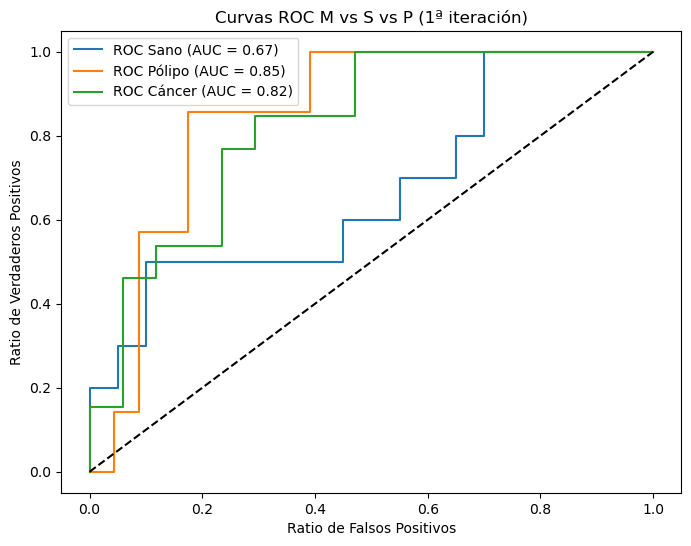

In [5]:
def procesar_nombres_muestra(ruta, umbral):
    """Extrae nombres y abundancias basados en la estructura real detectada."""
    try:
        df = pd.read_excel(ruta, header=None)
        mask = df.apply(lambda row: row.astype(str).str.contains('Library/ID', case=False, na=False)).any(axis=1)
        if not mask.any(): return set()
        idx_inicio = mask.idxmax()
        data = df.iloc[idx_inicio + 1:].copy()
        data[3] = pd.to_numeric(data[3], errors='coerce')
        filtro = (data[3] >= umbral) & (data[4].notna())
        nombres = data.loc[filtro, 4].astype(str).apply(lambda x: x.split('$$')[0].strip())
        return set(nombres)
    except Exception:
        return set()

# Procesamiento de todas las poblaciones para obtener el conteo global
conteo_global = []
for etiqueta, info in GRUPOS.items():
    dir_path = os.path.join(RUTA_BASE, info["carpeta"])
    for i in range(1, info["n"] + 1):
        file_path = os.path.join(dir_path, f"{info['prefijo']} ({i}).xlsx")
        if os.path.exists(file_path):
            nombres = procesar_nombres_muestra(file_path, UMBRAL)
            conteo_global.extend(list(nombres))

top_names_vector = pd.Series(conteo_global).value_counts().head(100).index.tolist()

rows = []
for etiqueta, info in GRUPOS.items():
    dir_path = os.path.join(RUTA_BASE, info["carpeta"])
    for i in range(1, info["n"] + 1):
        file_name = f"{info['prefijo']} ({i}).xlsx"
        file_path = os.path.join(dir_path, file_name)
        if os.path.exists(file_path):
            presentes = procesar_nombres_muestra(file_path, UMBRAL)
            presencia = {name: (1 if name in presentes else 0) for name in top_names_vector}
            rows.append({'File': file_name, 'State': etiqueta, **presencia})

df_final = pd.DataFrame(rows)
df_final.to_excel(OUTPUT_FILE, index=False)

# Analisis de Características y Preparación para el Modelo
X = df_final.drop(columns=['File', 'State'])
label_map = {'S': 0, 'P': 1, 'M': 2}
y = df_final['State'].map(label_map)
feature_names = list(X.columns)

# Limpieza de constantes
var_thresh = VarianceThreshold(threshold=0.0)
X_red = var_thresh.fit_transform(X)
feature_names = [f for f, s in zip(feature_names, var_thresh.get_support()) if s]

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_red)

# Métricas de similitud
sim_matrix = cosine_similarity(X_scaled)
X_eng = np.hstack((X_scaled, sim_matrix.mean(axis=1).reshape(-1, 1), X_scaled.mean(axis=1).reshape(-1, 1), X_scaled.std(axis=1).reshape(-1, 1)))
feature_names += ['Similitud_Media', 'Media_Fila', 'Std_Fila']

# Interacciones y Selección
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_eng)
poly_names = poly.get_feature_names_out(feature_names)

selector = SelectKBest(score_func=f_classif, k=50) 
X_final = selector.fit_transform(X_poly, y)
final_feature_names = [poly_names[i] for i in selector.get_support(indices=True)]

# Validación Cruzada Estratificada (20 iteraciones)
accuracies, precisions, recalls, f1s, aucs, specificities = [], [], [], [], [], []
N_CICLOS = 20
for ciclo in range(N_CICLOS):
    X_shuf, y_shuf = shuffle(X_final, y, random_state=ciclo)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=ciclo)
    for train_idx, test_idx in skf.split(X_shuf, y_shuf):
        X_train_cv, X_test_cv = X_shuf[train_idx], X_shuf[test_idx]
        y_train_cv, y_test_cv = y_shuf.iloc[train_idx], y_shuf.iloc[test_idx]
        
        model_cv = CatBoostClassifier(iterations=700, learning_rate=0.05, depth=6, random_state=42, verbose=0)
        model_cv.fit(X_train_cv, y_train_cv)
        
        y_pred_cv = model_cv.predict(X_test_cv)
        y_prob_cv = model_cv.predict_proba(X_test_cv)
        
        # Métricas
        accuracies.append(accuracy_score(y_test_cv, y_pred_cv))
        precisions.append(precision_score(y_test_cv, y_pred_cv, average='weighted'))
        recalls.append(recall_score(y_test_cv, y_pred_cv, average='weighted'))
        f1s.append(f1_score(y_test_cv, y_pred_cv, average='weighted'))
        aucs.append(roc_auc_score(y_test_cv, y_prob_cv, multi_class='ovr', average='weighted'))
        
        # Cálculo de Especificidad (Promedio macro de One-vs-Rest)
        cm = confusion_matrix(y_test_cv, y_pred_cv)
        specs_per_class = []
        for i in range(len(label_map)):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp
            tn = cm.sum() - (tp + fp + fn)
            specs_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        specificities.append(np.mean(specs_per_class))

# Resultados
warnings.filterwarnings("ignore")

metricas = {
    'acc': accuracies,
    'sens': recalls,
    'spec': specificities,
    'prec': precisions,
    'f1': f1s,
    'auc': aucs,
}
med = {k: np.median(v) for k, v in metricas.items()}
std = {k: np.std(v) for k, v in metricas.items()}

print(f"Métricas ({N_CICLOS} Iteraciones) - MEDIANA ± DESV. EST.")
print(f"Exactitud:       {med['acc']*100:.1f}%  (± {std['acc']*100:.1f}%)")
print(f"Sensibilidad:    {med['sens']*100:.1f}% (± {std['sens']*100:.1f}%)")
print(f"Especificidad:   {med['spec']*100:.1f}% (± {std['spec']*100:.1f}%)")
print(f"Precisión:       {med['prec']*100:.1f}% (± {std['prec']*100:.1f}%)")
print(f"F1-Score:        {med['f1']:.3f}   (± {std['f1']:.3f})")
print(f"AUC ROC:         {med['auc']:.3f}   (± {std['auc']:.3f})")

# Entrenamiento Final y Evaluación Detallada
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
model = CatBoostClassifier(iterations=700, learning_rate=0.05, depth=6, random_state=42, verbose=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Curva ROC Multiclase
plt.figure(figsize=(8, 6))
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
for i, label in enumerate(['Sano', 'Pólipo', 'Cáncer']):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'ROC {label} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Ratio de Falsos Positivos')
plt.ylabel('Ratio de Verdaderos Positivos')
plt.title('Curvas ROC M vs S vs P (1ª iteración)')
plt.legend()
plt.show()

# Ahora hare 3 comparaciones, M-S, M-P, S-P

### Análisis Comparativo: Enfermos (M) frente a Sanos (S)
En esta sección se evalúa la capacidad diagnóstica del modelo para distinguir pacientes con CCR de pacientes sanos:

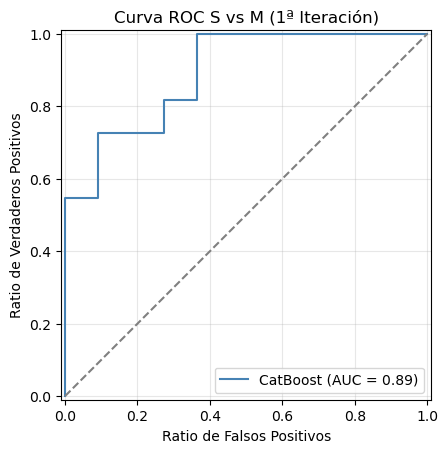

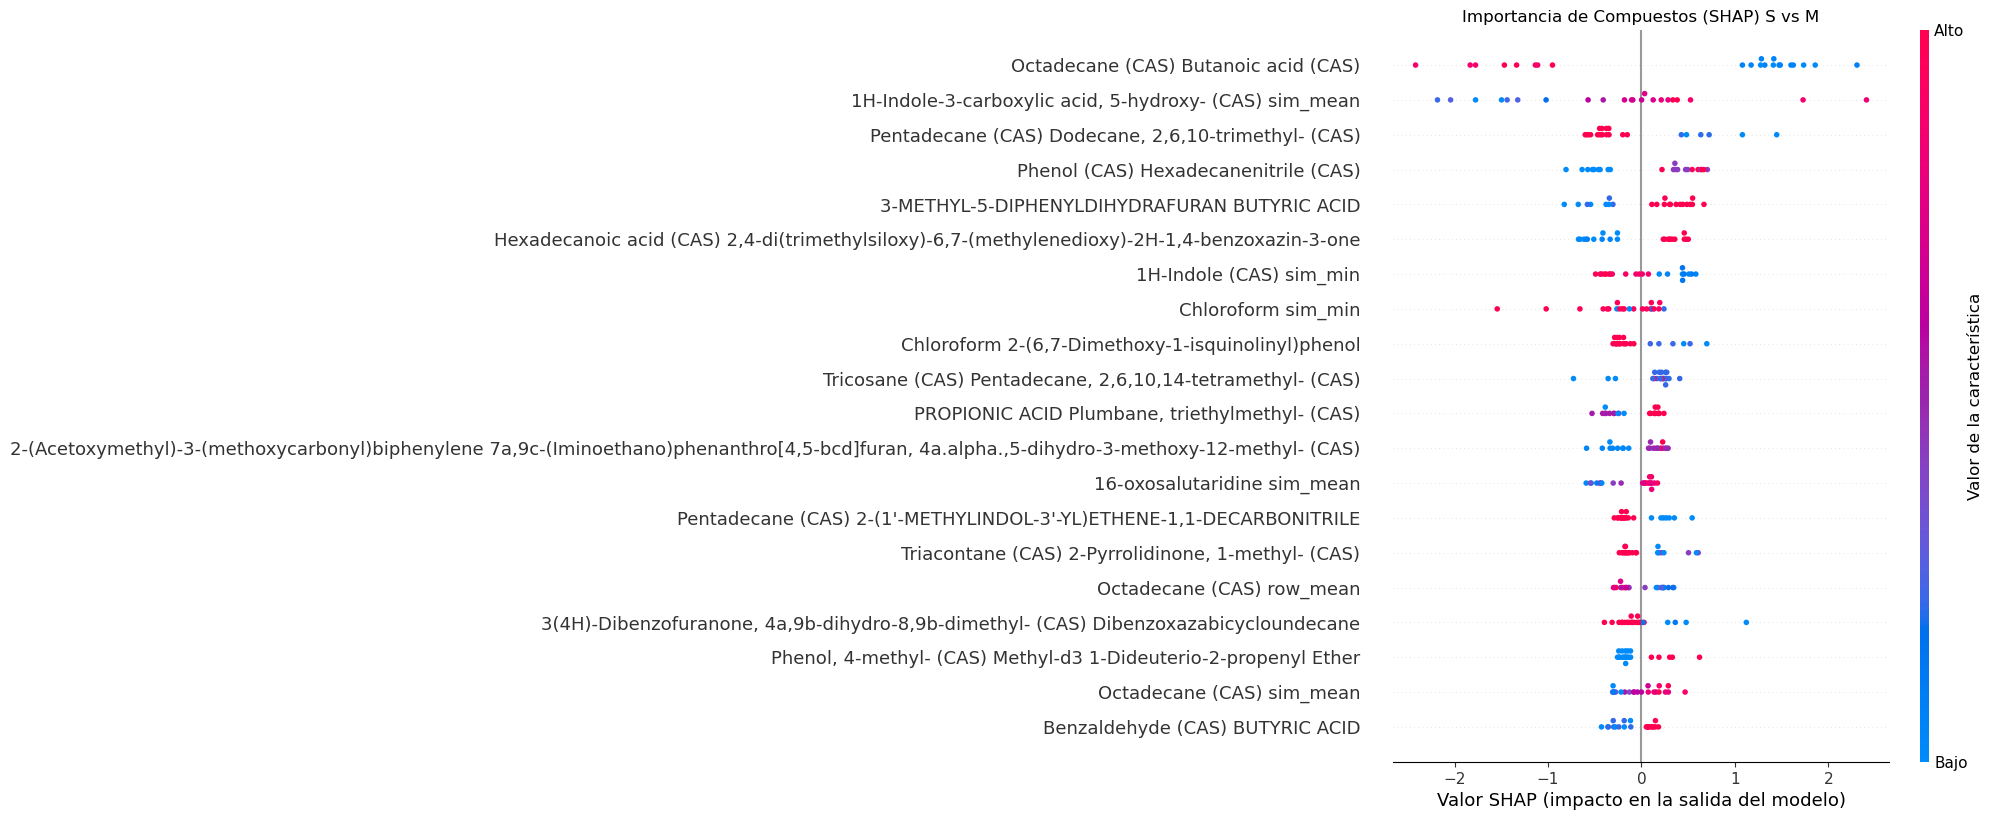

Métricas (20 Iteraciones) - MEDIANA ± DESV. EST.
Exactitud:       77.3%  (± 10.8%)
Sensibilidad:    84.0% (± 9.3%)
Especificidad:   69.6% (± 19.2%)
Precisión:       76.0% (± 13.6%)
F1-Score:        0.776   (± 0.091)
AUC ROC:         0.876   (± 0.111)


In [ ]:
N_CICLOS = 20
df = pd.read_excel('data_prepared.xlsx')
df = df[df['State'].isin(['S', 'M'])].copy()

X_raw = df.drop(columns=['File', 'State'])
# Definimos M como 1 y S como 0, presencia y ausencia
y = df['State'].apply(lambda x: 1 if x == 'M' else 0)

feature_names = list(X_raw.columns)

# Filtro de varianza para eliminar características constantes
var_thresh = VarianceThreshold(threshold=0.0)
X = var_thresh.fit_transform(X_raw)
feature_names = [feature_names[i] for i in var_thresh.get_support(indices=True)]

# Escalado
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Correlaciones
sim_matrix = cosine_similarity(X)
sim_mean = sim_matrix.mean(axis=1).reshape(-1, 1)
sim_max = sim_matrix.max(axis=1).reshape(-1, 1)
sim_min = sim_matrix.min(axis=1).reshape(-1, 1)

X = np.hstack((X, sim_mean, sim_max, sim_min))
feature_names += ['sim_mean', 'sim_max', 'sim_min']

# Estadísticas por fila
row_stats = np.hstack((
    X.mean(axis=1).reshape(-1, 1), 
    X.std(axis=1).reshape(-1, 1), 
    X.max(axis=1).reshape(-1, 1), 
    X.min(axis=1).reshape(-1, 1)
))
X = np.hstack((X, row_stats))
feature_names += ['row_mean', 'row_std', 'row_max', 'row_min']

# Interacciones polinómicas
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(feature_names)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Selección de características
selector = SelectKBest(score_func=f_classif, k=50)
X = selector.fit_transform(X, y)
feature_names = [feature_names[i] for i in selector.get_support(indices=True)]

# Entrenamiento y Evaluación con CatBoost
model = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, random_state=42, verbose=0)

accuracies, precisions, recalls, f1s, aucs, specificities = [], [], [], [], [], []

for i in range(N_CICLOS):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, zero_division=1))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    if i == 0:
        # Visualización Curva ROC 
        RocCurveDisplay.from_predictions(y_test, y_prob, color='steelblue', name='CatBoost')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        -plt.title(f"Curva ROC M vs S (1ª Iteración)")
        plt.xlabel('Ratio de Falsos Positivos')
        plt.ylabel('Ratio de Verdaderos Positivos')
        plt.grid(alpha=0.3)
        plt.show()

        # Visualización SHAP
        X_test_df = pd.DataFrame(X_test, columns=feature_names)
        explainer = shap.Explainer(model)
        shap_values = explainer(X_test_df)
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test_df, show=False)
        plt.title("Importancia de Compuestos (SHAP) M vs S")
        plt.grid(False)
        plt.xlabel("Valor SHAP (impacto en la salida del modelo)")
        fig = plt.gcf()
        cb_ax = fig.axes[-1] 
        cb_ax.set_ylabel("Valor de la característica")
        cb_ax.set_yticklabels(["Bajo", "Alto"])
        plt.show()

# Resultados 
warnings.filterwarnings("ignore")

metricas = {
    'acc': accuracies,
    'sens': recalls,
    'spec': specificities,
    'prec': precisions,
    'f1': f1s,
    'auc': aucs,
}
med = {k: np.median(v) for k, v in metricas.items()}
std = {k: np.std(v) for k, v in metricas.items()}

print(f"Métricas ({N_CICLOS} Iteraciones) - MEDIANA ± DESV. EST.")
print(f"Exactitud:       {med['acc']*100:.1f}%  (± {std['acc']*100:.1f}%)")
print(f"Sensibilidad:    {med['sens']*100:.1f}% (± {std['sens']*100:.1f}%)")
print(f"Especificidad:   {med['spec']*100:.1f}% (± {std['spec']*100:.1f}%)")
print(f"Precisión:       {med['prec']*100:.1f}% (± {std['prec']*100:.1f}%)")
print(f"F1-Score:        {med['f1']:.3f}   (± {std['f1']:.3f})")
print(f"AUC ROC:         {med['auc']:.3f}   (± {std['auc']:.3f})")

### Análisis Comparativo: Enfermos (M) frente a Pólipos (P)
Se analiza la capacidad del modelo para diferenciar entre una lesión premaligna (pólipo) y CCR:

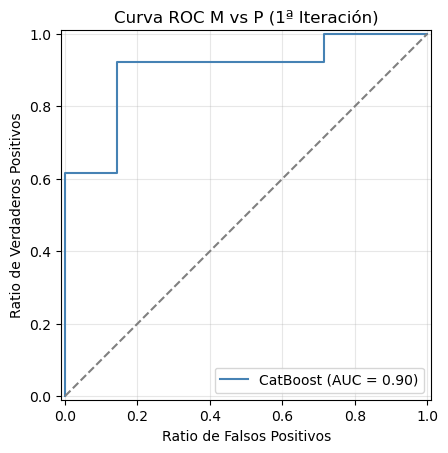

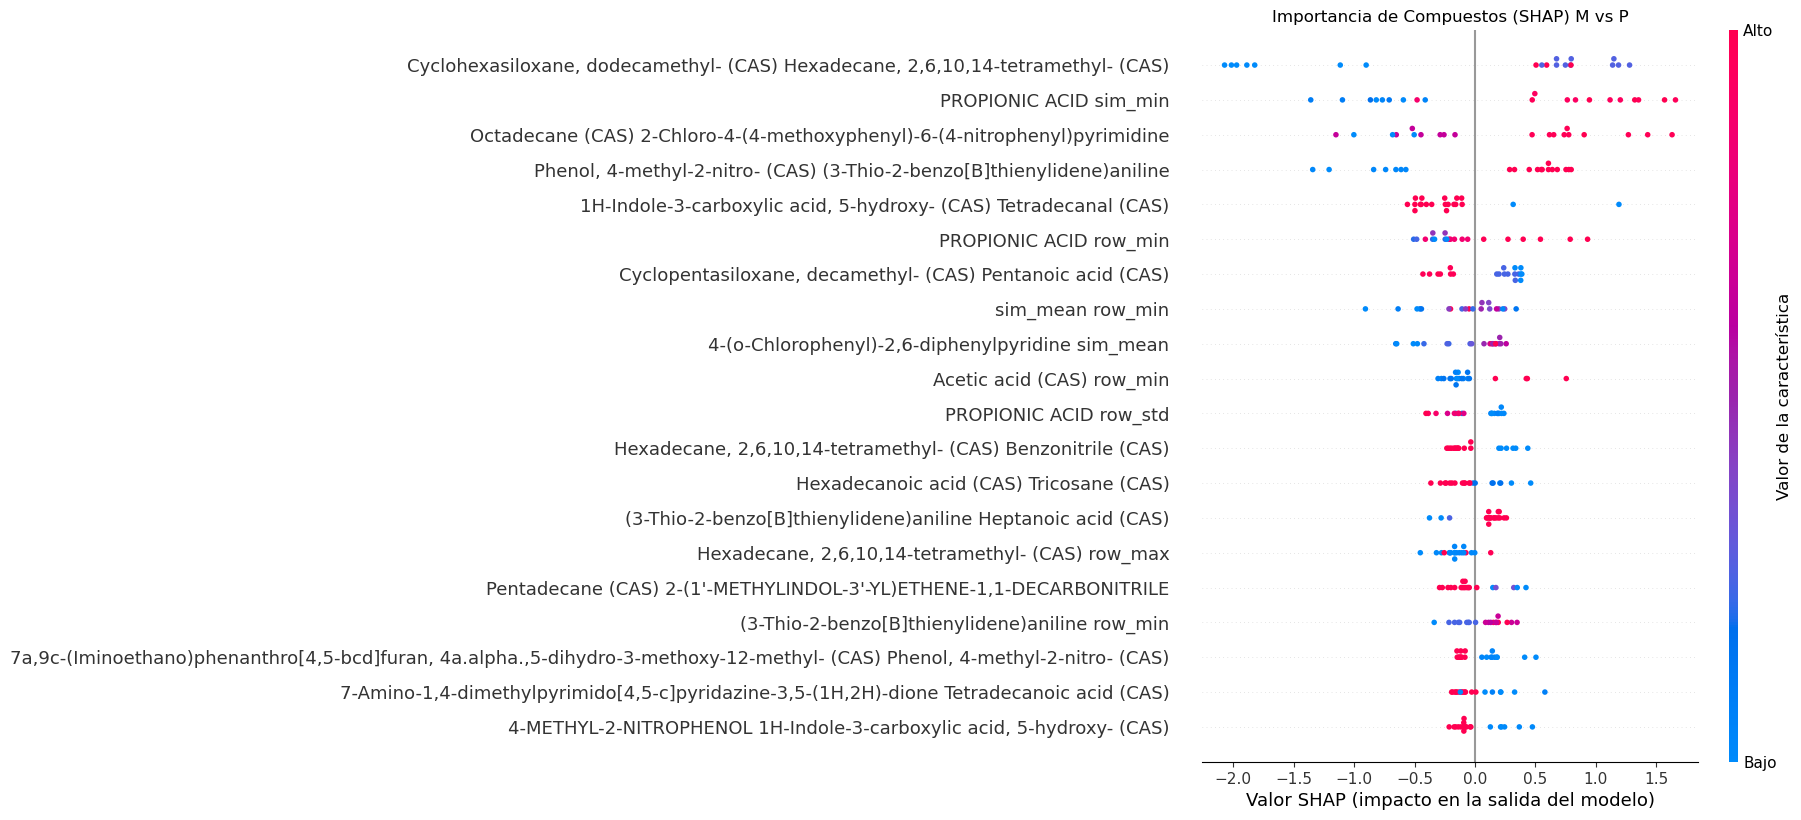

Métricas (20 Iteraciones) - MEDIANA ± DESV. EST.
Exactitud:       75.0%  (± 9.2%)
Sensibilidad:    76.0% (± 14.8%)
Especificidad:   75.0% (± 15.7%)
Precisión:       81.8% (± 10.0%)
F1-Score:        0.783   (± 0.103)
AUC ROC:         0.833   (± 0.074)


In [8]:
N_CICLOS = 20
df = pd.read_excel('data_prepared.xlsx')
df = df[df['State'].isin(['M', 'P'])].copy()

X_raw = df.drop(columns=['File', 'State'])
y = df['State'].apply(lambda x: 1 if x == 'M' else 0)

feature_names = list(X_raw.columns)

# Limpieza
var_thresh = VarianceThreshold(threshold=0.0)
X = var_thresh.fit_transform(X_raw)
feature_names = [feature_names[i] for i in var_thresh.get_support(indices=True)]

# Escalado
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Correlaciones
sim_matrix = cosine_similarity(X)
sim_mean = sim_matrix.mean(axis=1).reshape(-1, 1)
sim_max = sim_matrix.max(axis=1).reshape(-1, 1)
sim_min = sim_matrix.min(axis=1).reshape(-1, 1)

X = np.hstack((X, sim_mean, sim_max, sim_min))
feature_names += ['sim_mean', 'sim_max', 'sim_min']

# Estadisticas por fila
row_stats = np.hstack((
    X.mean(axis=1).reshape(-1, 1), 
    X.std(axis=1).reshape(-1, 1), 
    X.max(axis=1).reshape(-1, 1), 
    X.min(axis=1).reshape(-1, 1)
))
X = np.hstack((X, row_stats))
feature_names += ['row_mean', 'row_std', 'row_max', 'row_min']

# Interacciones polinomicas
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(feature_names)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Selección de características
selector = SelectKBest(score_func=f_classif, k=50)
X = selector.fit_transform(X, y)
feature_names = [feature_names[i] for i in selector.get_support(indices=True)]

# Modelo y Evaluación
model = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, random_state=42, verbose=0)

accuracies, precisions, recalls, f1s, aucs, specificities = [], [], [], [], [], []

for i in range(N_CICLOS):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Métricas
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, zero_division=1))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    if i == 0:
        # Visualización Curva ROC
        RocCurveDisplay.from_predictions(y_test, y_prob, color='steelblue', name='CatBoost')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.title(f"Curva ROC M vs P (1ª Iteración)")
        plt.xlabel('Ratio de Falsos Positivos')
        plt.ylabel('Ratio de Verdaderos Positivos')
        plt.grid(alpha=0.3)
        plt.show() 

        # Visualización SHAP
        X_test_df = pd.DataFrame(X_test, columns=feature_names)
        explainer = shap.Explainer(model)
        shap_values = explainer(X_test_df)
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test_df, show=False)
        plt.title("Importancia de Compuestos (SHAP) M vs P")
        plt.grid(False)
        plt.xlabel("Valor SHAP (impacto en la salida del modelo)")
        fig = plt.gcf()
        cb_ax = fig.axes[-1] 
        cb_ax.set_ylabel("Valor de la característica")
        cb_ax.set_yticklabels(["Bajo", "Alto"])
        plt.show()

        

# Resultados
warnings.filterwarnings("ignore")

metricas = {
    'acc': accuracies,
    'sens': recalls,
    'spec': specificities,
    'prec': precisions,
    'f1': f1s,
    'auc': aucs,
}
med = {k: np.median(v) for k, v in metricas.items()}
std = {k: np.std(v) for k, v in metricas.items()}

print(f"Métricas ({N_CICLOS} Iteraciones) - MEDIANA ± DESV. EST.")
print(f"Exactitud:       {med['acc']*100:.1f}%  (± {std['acc']*100:.1f}%)")
print(f"Sensibilidad:    {med['sens']*100:.1f}% (± {std['sens']*100:.1f}%)")
print(f"Especificidad:   {med['spec']*100:.1f}% (± {std['spec']*100:.1f}%)")
print(f"Precisión:       {med['prec']*100:.1f}% (± {std['prec']*100:.1f}%)")
print(f"F1-Score:        {med['f1']:.3f}   (± {std['f1']:.3f})")
print(f"AUC ROC:         {med['auc']:.3f}   (± {std['auc']:.3f})")

### Análisis Comparativo: Sanos (S) frente a Pólipos (P)

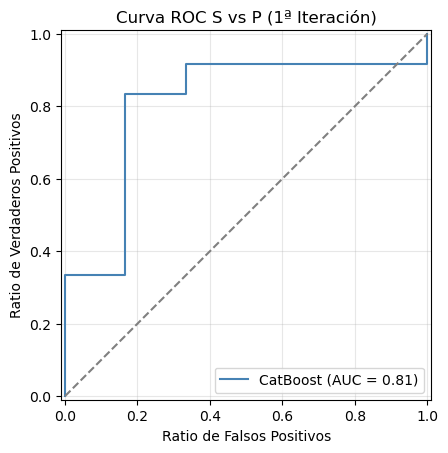

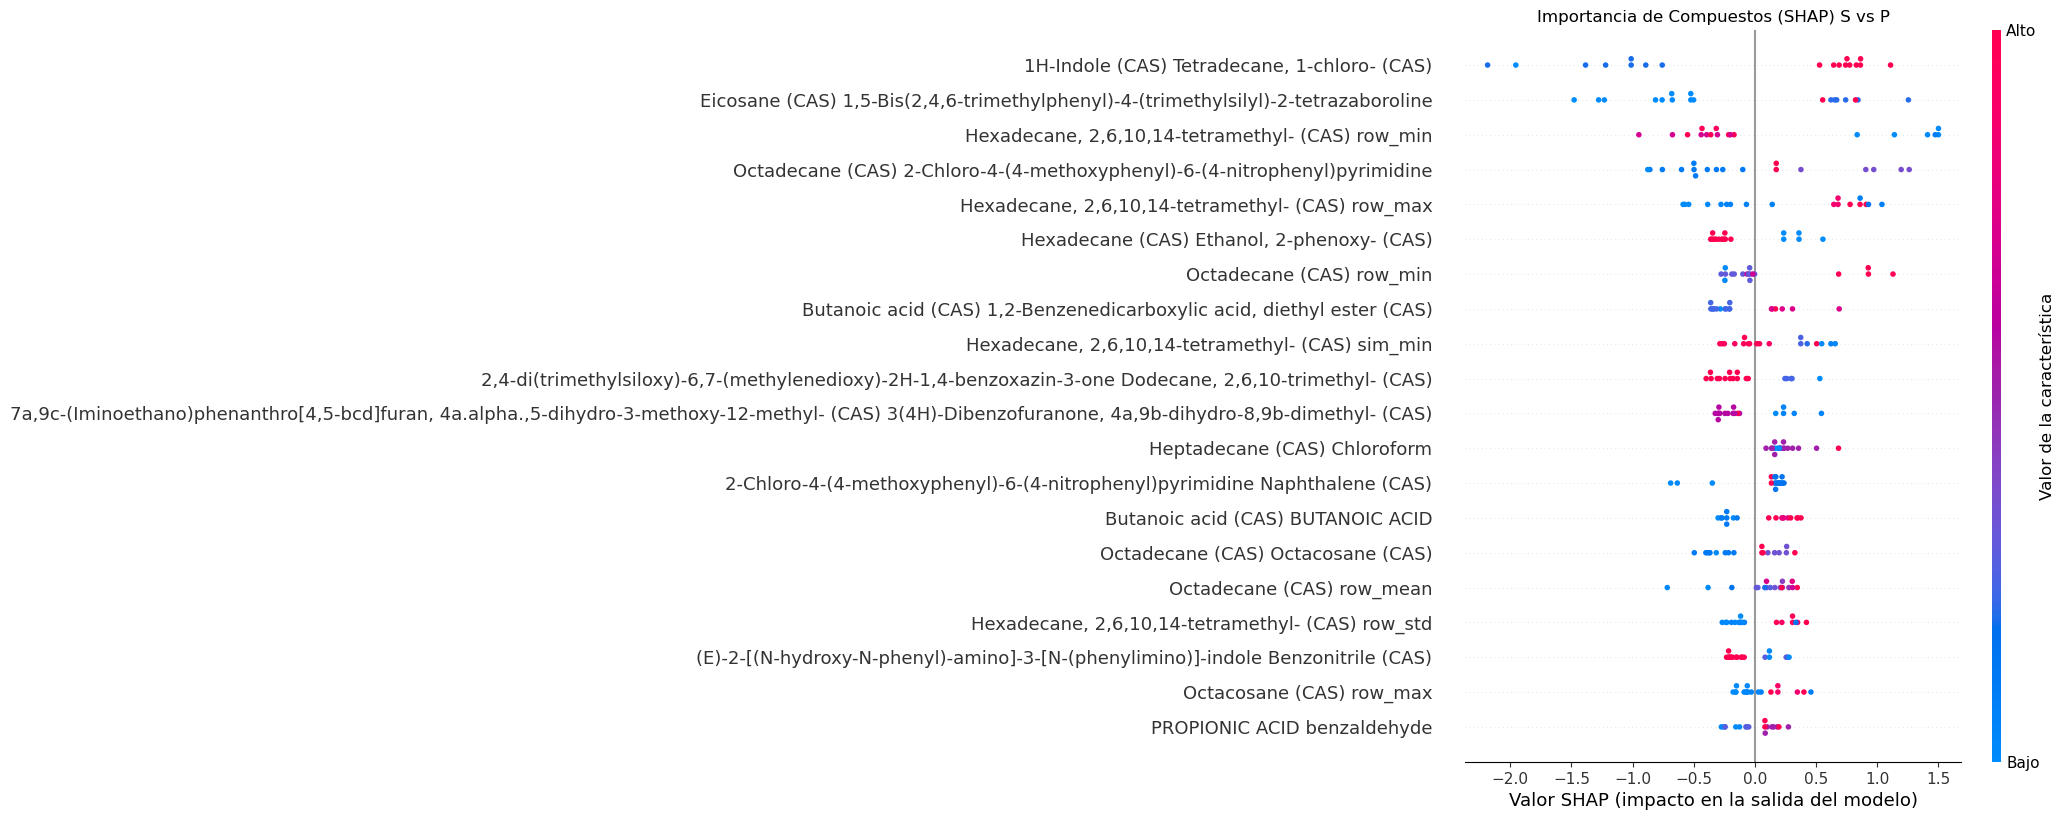

Métricas (20 Iteraciones) - MEDIANA ± DESV. EST.
Exactitud:       83.3%  (± 7.9%)
Sensibilidad:    85.4% (± 14.0%)
Especificidad:   83.3% (± 12.2%)
Precisión:       90.0% (± 11.6%)
F1-Score:        0.833   (± 0.104)
AUC ROC:         0.861   (± 0.082)


In [10]:
N_CICLOS = 20
df = pd.read_excel('data_prepared.xlsx')
df = df[df['State'].isin(['S', 'P'])].copy()
X_raw = df.drop(columns=['File', 'State'])
y = df['State'].apply(lambda x: 1 if x == 'S' else 0)

feature_names = list(X_raw.columns)

# Preprocesamiento 
var_thresh = VarianceThreshold(threshold=0.0)
X = var_thresh.fit_transform(X_raw)
feature_names = [feature_names[i] for i in var_thresh.get_support(indices=True)]

scaler = StandardScaler()
X = scaler.fit_transform(X)

sim_matrix = cosine_similarity(X)
sim_mean = sim_matrix.mean(axis=1).reshape(-1, 1)
sim_max = sim_matrix.max(axis=1).reshape(-1, 1)
sim_min = sim_matrix.min(axis=1).reshape(-1, 1)

X = np.hstack((X, sim_mean, sim_max, sim_min))
feature_names += ['sim_mean', 'sim_max', 'sim_min']

row_stats = np.hstack((
    X.mean(axis=1).reshape(-1, 1), 
    X.std(axis=1).reshape(-1, 1),
    X.max(axis=1).reshape(-1, 1),
    X.min(axis=1).reshape(-1, 1)
))
X = np.hstack((X, row_stats))
feature_names += ['row_mean', 'row_std', 'row_max', 'row_min']

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(feature_names)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

selector = SelectKBest(score_func=f_classif, k=50)
X = selector.fit_transform(X, y)
feature_names = [feature_names[i] for i in selector.get_support(indices=True)]

# Modelo y Evaluación 
model = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, random_state=42, verbose=0)

accuracies, precisions, recalls, f1s, aucs, specificities = [], [], [], [], [], []

for i in range(N_CICLOS):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, zero_division=1))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    current_auc = auc(fpr, tpr)
    aucs.append(current_auc)

    if i == 0:
        # Visualización Curva ROC
        RocCurveDisplay.from_predictions(y_test, y_prob, color='steelblue', name='CatBoost')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.title(f"Curva ROC S vs P (1ª Iteración)")
        plt.xlabel('Ratio de Falsos Positivos')
        plt.ylabel('Ratio de Verdaderos Positivos')
        plt.grid(alpha=0.3)
        plt.show() 


        # Visualización SHAP
        X_test_df = pd.DataFrame(X_test, columns=feature_names)
        explainer = shap.Explainer(model)
        shap_values = explainer(X_test_df)
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test_df, show=False)
        plt.title("Importancia de Compuestos (SHAP) S vs P")
        plt.grid(False)
        plt.xlabel("Valor SHAP (impacto en la salida del modelo)")
        fig = plt.gcf()
        cb_ax = fig.axes[-1] 
        cb_ax.set_ylabel("Valor de la característica")
        cb_ax.set_yticklabels(["Bajo", "Alto"])
        plt.show()

# Cálculo de Mediana y Desviación 
med = {
    'acc': np.median(accuracies),
    'sens': np.median(recalls),
    'spec': np.median(specificities),
    'prec': np.median(precisions),
    'f1': np.median(f1s),
    'auc': np.median(aucs)
}

std = {
    'acc': np.std(accuracies),
    'sens': np.std(recalls),
    'spec': np.std(specificities),
    'prec': np.std(precisions),
    'f1': np.std(f1s),
    'auc': np.std(aucs)
}
# Resultados
print(f"Métricas ({N_CICLOS} Iteraciones) - MEDIANA ± DESV. EST.")
print(f"Exactitud:       {med['acc']*100:.1f}%  (± {std['acc']*100:.1f}%)")
print(f"Sensibilidad:    {med['sens']*100:.1f}% (± {std['sens']*100:.1f}%)")
print(f"Especificidad:   {med['spec']*100:.1f}% (± {std['spec']*100:.1f}%)")
print(f"Precisión:       {med['prec']*100:.1f}% (± {std['prec']*100:.1f}%)")
print(f"F1-Score:        {med['f1']:.3f}   (± {std['f1']:.3f})")
print(f"AUC ROC:         {med['auc']:.3f}   (± {std['auc']:.3f})")

### Cribado Global: Enfermos (M+P) frente a Sanos (S)
En esta fase se agrupan las clases 'M' y 'P' en una sola categoría de "Positivos" para simular un escenario real de cribado:

<Figure size 700x500 with 0 Axes>

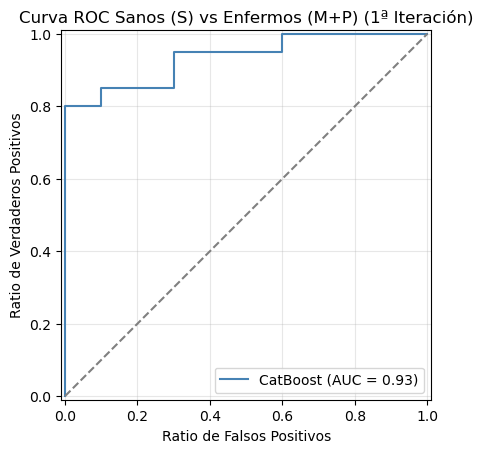

Métricas (20 Iteraciones) - MEDIANA ± DESV. EST.
Exactitud:      0.823 ± 0.052
Precisión:     0.887 ± 0.067
Sensibilidad: 0.852 ± 0.090
Especificidad: 0.765 ± 0.153
F1-Score:      0.864 ± 0.045
AUC:           0.818 ± 0.076


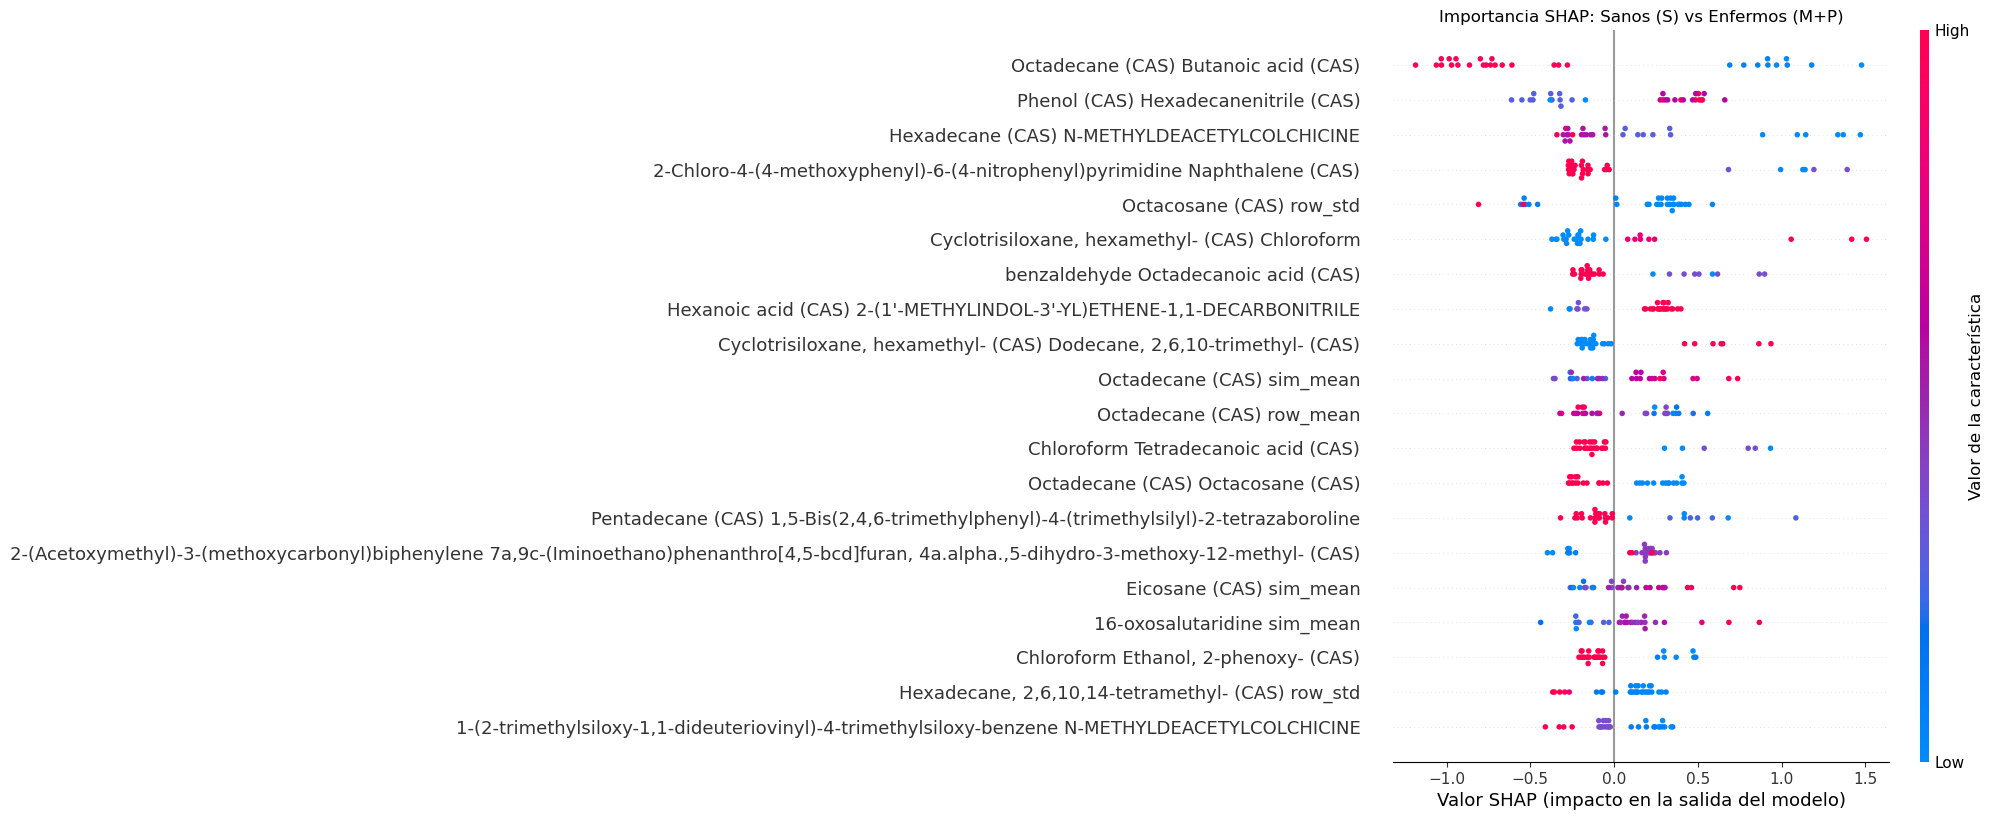

In [ ]:
# Carga y preparación de datos para S vs P
df = pd.read_excel('data_prepared.xlsx')
df['Binary_State'] = df['State'].apply(lambda x: 1 if x in ['M', 'P'] else 0)

X_raw = df.drop(columns=['File', 'State', 'Binary_State'])
y = df['Binary_State']
feature_names_raw = list(X_raw.columns)

# Ingenieria de características
var_thresh = VarianceThreshold(threshold=0.0)
X_clean = var_thresh.fit_transform(X_raw)
feature_names = [feature_names_raw[i] for i in var_thresh.get_support(indices=True)]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Similitudes y estadísticas
sim_matrix = cosine_similarity(X_scaled)
X_eng = np.hstack((
    X_scaled,
    sim_matrix.mean(axis=1).reshape(-1, 1),
    X_scaled.mean(axis=1).reshape(-1, 1),
    X_scaled.std(axis=1).reshape(-1, 1)
))
feature_names += ['sim_mean', 'row_mean', 'row_std']

# Interacciones y selección (K=40 para evitar ruido)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_eng)
poly_names = poly.get_feature_names_out(feature_names)

X_poly = np.nan_to_num(X_poly)

selector = SelectKBest(score_func=f_classif, k=40)
X_final = selector.fit_transform(X_poly, y)
final_feature_names = [poly_names[i] for i in selector.get_support(indices=True)]

# Entrenamiento Final 
model = CatBoostClassifier(iterations=800, learning_rate=0.05, depth=6, l2_leaf_reg=10, random_seed=42, verbose=0)

accuracies, precisions, recalls, f1s, aucs, specificities = [], [], [], [], [], []

N_CICLOS = 20

for i in range(N_CICLOS):
    X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=i, stratify=y)
    
    # Balanceo sintético SMOTE-Tomek
    resampler = SMOTETomek(random_state=42)
    X_res, y_res = resampler.fit_resample(X_train, y_train)
    
    model.fit(X_res, y_res)
    
    # Obtener probabilidades
    y_prob = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    idx_optimo = np.argmax(tpr - fpr)
    umbral_voto = thresholds[idx_optimo]
    
    # Predicción final con el nuevo umbral
    y_pred = (y_prob >= umbral_voto).astype(int)
    
    # Métricas
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    aucs.append(auc(fpr, tpr))

    # Graficar primera iteración para control
    if i == 0:
        # Creamos una sola figura con tamaño estándar
        plt.figure(figsize=(7, 5))
        
        # Generamos la curva ROC directamente
        RocCurveDisplay.from_predictions(y_test, y_prob, color='steelblue', name='CatBoost')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.title(f"Curva ROC Sanos (S) vs Enfermos (M+P) (1ª Iteración)")
        plt.xlabel('Ratio de Falsos Positivos')
        plt.ylabel('Ratio de Verdaderos Positivos')
        plt.grid(alpha=0.3)
        plt.show()

# Resultados 
print(f"Métricas ({N_CICLOS} Iteraciones) - MEDIANA ± DESV. EST.")
print(f"Exactitud:      {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisión:     {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Sensibilidad: {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"Especificidad: {np.mean(specificities):.3f} ± {np.std(specificities):.3f}")
print(f"F1-Score:      {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AUC:           {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

# SHAP Global
X_test_df = pd.DataFrame(X_test, columns=final_feature_names)
explainer = shap.Explainer(model)
shap_values = explainer(X_test_df)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("Importancia SHAP: Sanos (S) vs Enfermos (M+P)")
plt.grid(False)
plt.xlabel("Valor SHAP (impacto en la salida del modelo)")
fig = plt.gcf()
cb_ax = fig.axes[-1] 
cb_ax.set_ylabel("Valor de la característica")
plt.show()